Text(0.5, 1.0, 'Comparing Local Error for Values of h')

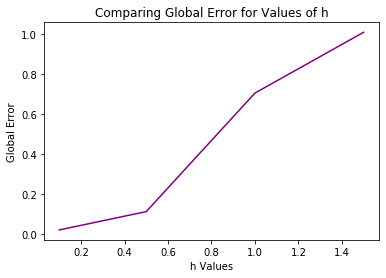

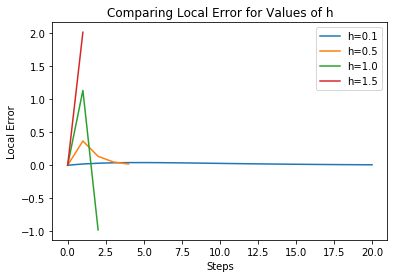

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def exact(x):
    return np.exp(-2*x)
    
def errors(h,x,y):
    glerr=0
    lerr=[]
    for i in range(len(x)):
        ye=exact(x[i])
        glerr+=abs(ye-y[i])
        lerr.append(ye-y[i])
    glerr=glerr/len(x)
    
    return glerr,lerr
    
globe=[]
local=[]
hs = np.array([.1,.5,1,1.5])  # step size
x_start, x_end = 0, 2

def f(x, y):
    return -2 * y

for h in hs:
    num_steps = int((x_end - x_start) / h)
    x_values=np.linspace(x_start, x_end, num_steps + 1)
    y_values=np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
    globalerror,localerror=errors(h,x_values,y_values)
        
    globe.append(globalerror)
    local.append(localerror)

    
    
plt.figure()
plt.plot(hs,globe,color='purple')
plt.xlabel('h Values')
plt.ylabel('Global Error')
plt.title('Comparing Global Error for Values of h')

plt.figure()
for i in range(len(hs)):
    plt.plot(local[i],label=f'h={hs[i]}')
plt.ylabel('Local Error')
plt.xlabel('Steps')
plt.legend()
plt.title('Comparing Local Error for Values of h')
